In [1]:
import numpy as np
import healpy as hp
import pysm3 as sm

import matplotlib as mpl
import matplotlib.pyplot as plt

import cmasher as cmr
import seaborn as sns

import sys
sys.path.append('../')

from src.utils import pretty_axes, modify_rc, w_object, patch_creation, get_patch_data, bbox_props
modify_rc()
modify_rc()
from src import synthesize


In [2]:
NSIDE = 512
LMAX = 3*NSIDE - 1

ells = np.arange(LMAX+1)

sky6 = sm.Sky(nside=NSIDE, preset_strings=['s6'])

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [3]:
t0, e0, b0 = hp.alm2map(sky6.components[0].template_largescale_alm.value, NSIDE, pol=False)
cls0 = hp.anafast([t0, e0, b0], lmax=LMAX, pol=False)
cl_t0, cl_e0, cl_b0, cl_te0 = cls0[0], cls0[1], cls0[2], cls0[3]

In [4]:
mod_mapI = hp.alm2map(sky6.components[0].modulate_alm[0].value, NSIDE)
mod_mapP = hp.alm2map(sky6.components[0].modulate_alm[1].value, NSIDE)

In [5]:
cl_tt = sky6.components[0].small_scale_cl[0][:LMAX+1].value
cl_tt[cl_tt == 0.] = 1e-15
cl_ee = sky6.components[0].small_scale_cl[1][:LMAX+1].value
cl_ee[cl_ee == 0.] = 1e-15
cl_bb = sky6.components[0].small_scale_cl[2][:LMAX+1].value
cl_bb[cl_bb == 0.] = 1e-15
cl_te = sky6.components[0].small_scale_cl[3][:LMAX+1].value
cl_te[cl_te == 0.] = 1e-15

cl_tt = np.float64(cl_tt)
cl_ee = np.float64(cl_ee)
cl_bb = np.float64(cl_bb)
cl_te = np.float64(cl_te)

/tmp/ipykernel_69128/3675592422.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  cl_tt = np.float64(cl_tt)
/tmp/ipykernel_69128/3675592422.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  cl_ee = np.float64(cl_ee)
/tmp/ipykernel_69128/3675592422.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  cl_bb = np.float64(cl_bb)
/tmp/ipykernel_69128/3675592422.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  cl_te = np.float64(cl_te)


In [6]:
import kea
from kea.statistics.spectra import fourier_modal_spectrum, bin_spectrum
FEKS_TT = []
FEKS_EE = []
FEKS_BB = []
FEKS_TE = []

In [7]:
L_CENTER = 318.0
B_CENTER = -61.0

In [8]:
C_VAL = 5.0
LAMBDA_VAL = 0.25
LARGE_C = 2.5

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te,
    seeds=(1,2,3))
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS = np.zeros((1, 5, np.shape(img)[0], np.shape(img)[1]))
IMGS[0,0,:,:] = img
IMGS_DELTA = np.zeros((1, 5, np.shape(img)[0], np.shape(img)[1]))
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[0,0,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/

In [9]:
i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te,
    seeds=(4,5,6))
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[0,1,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[0,1,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_TE.append((k, fek))

Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/

In [10]:
i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te,
    seeds=(7,8,9))
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[0,2,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[0,2,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_TE.append((k, fek))

Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/

In [11]:
i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te,
    seeds=(10,11,12))
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[0,3,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[0,3,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_TE.append((k, fek))

Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/

In [12]:
i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te,
    seeds=(13,14,15))
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[0,4,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[0,4,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'averaged')
FEKS_TE.append((k, fek))

Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/

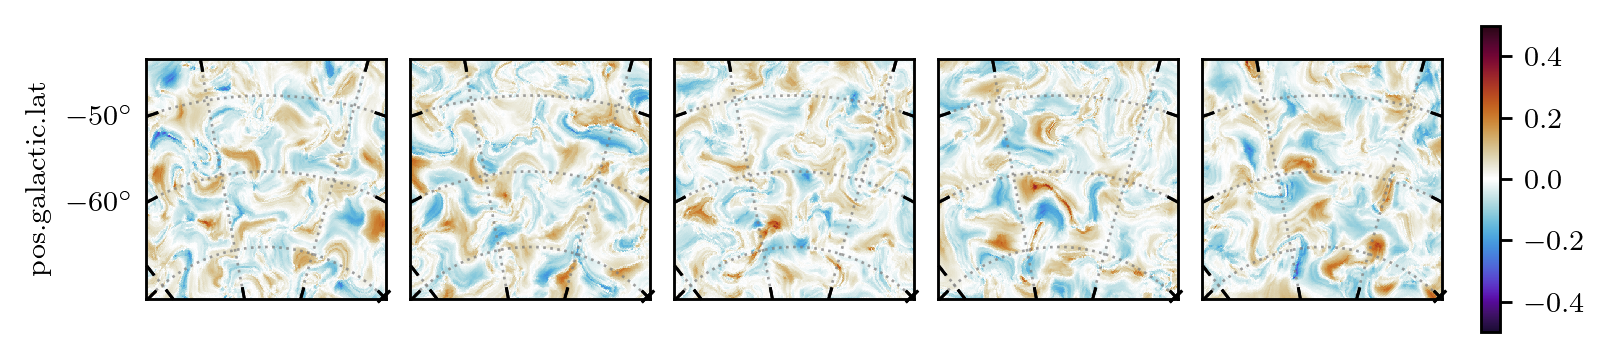

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.wcs import WCS

xsize = IMGS_DELTA.shape[-1]
w = WCS(naxis=2)
w.wcs.crpix = [xsize / 2.0 + 0.5, xsize / 2.0 + 0.5]
w.wcs.crval = [L_CENTER, B_CENTER]

w.wcs.cdelt = np.array([-4.94 / 60.0, 4.94 / 60.0])
w.wcs.ctype = ["GLON-TAN", "GLAT-TAN"]

fig = plt.figure(figsize=(7.5, 1.75), dpi=256)

ax = [fig.add_subplot(1, 5, 1, projection=w), fig.add_subplot(1, 5, 2, projection=w), fig.add_subplot(1, 5, 3, projection=w), fig.add_subplot(1, 5, 4, projection=w), fig.add_subplot(1, 5, 5, projection=w)]
ax = [ax,]

fusion_cmap = cmr.fusion_r

for i in range(1):
    for j in range(5):
        im = ax[i][j].imshow(IMGS_DELTA[i, j], cmap=fusion_cmap, origin='lower', 
                             interpolation='none', vmin=-0.5, vmax=0.5)
        
        ax[i][j].coords.grid(color='white', alpha=0.4, linestyle='dashed')
        
        lon = ax[i][j].coords[0]
        lat = ax[i][j].coords[1]

        if j > 0:
            lat.set_ticklabel_visible(False)
        if i < 3:
            lon.set_ticklabel_visible(False)

for axs in ax:
    for axx in axs:
        axx.yaxis.set_ticks_position('both')
        axx.xaxis.set_ticks_position('both')
        axx.tick_params(axis='y', direction='in')
        axx.tick_params(axis='x', direction='in')
        axx.grid(linestyle=':', alpha=0.75, linewidth=0.75, color='gray')
        # axx.set_yticklabels([])
        # axx.set_xticklabels([])

fig.subplots_adjust(wspace=0.1, hspace=-0.275, right=0.8)
cbar_ax = fig.add_axes([0.82, 0.1525, 0.01, 0.685])
fig.colorbar(im, cax=cbar_ax)

fig.savefig('plots/small_scale_realizations.pdf', pad_inches=0.1, bbox_inches='tight')

<>:67: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:67: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_69128/2203764005.py:67: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  cbar_ax.set_ylabel('$\mu\mathrm{K}_\mathrm{RJ}$')


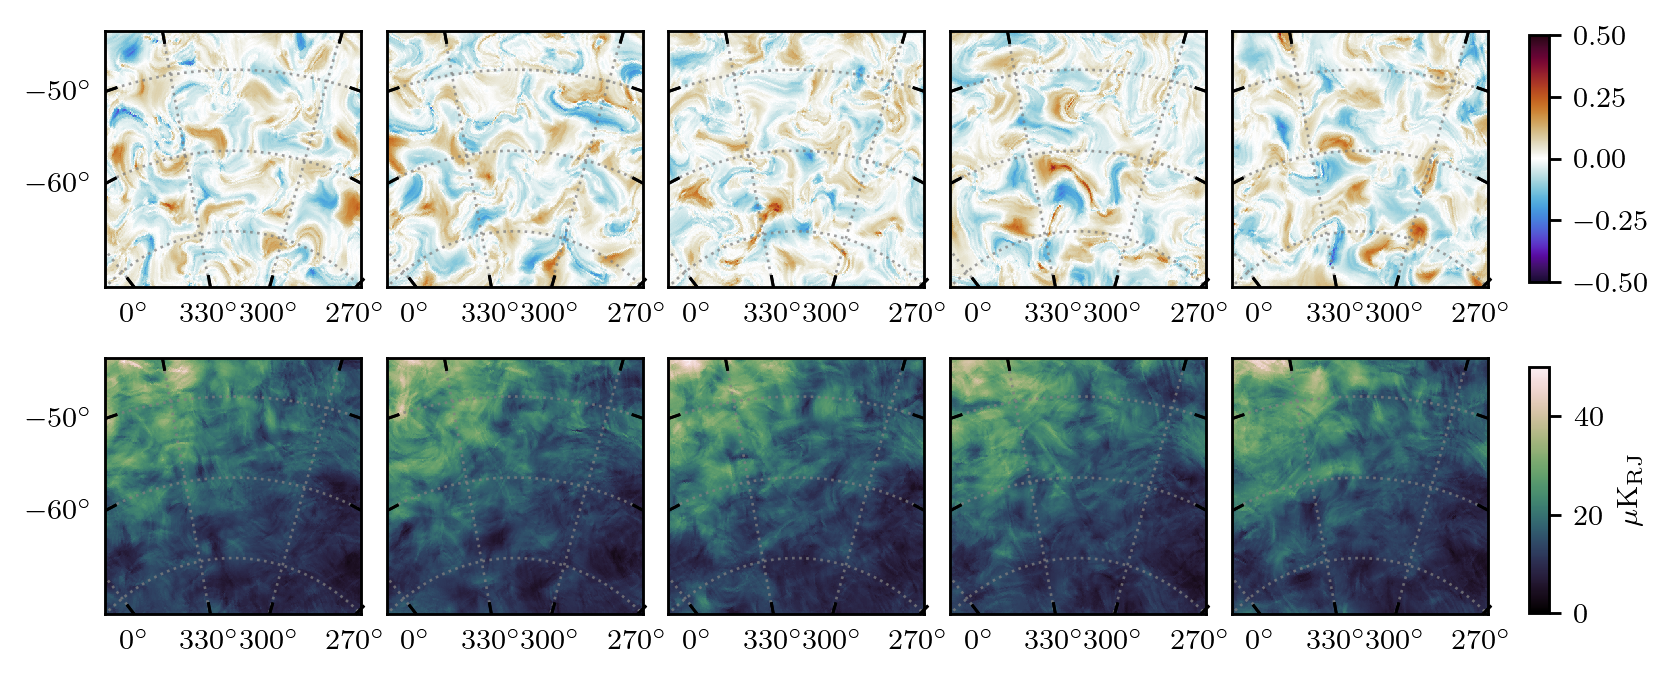

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.wcs import WCS

xsize = IMGS_DELTA.shape[-1]
w = WCS(naxis=2)
w.wcs.crpix = [xsize / 2.0 + 0.5, xsize / 2.0 + 0.5]
w.wcs.crval = [L_CENTER, B_CENTER]

w.wcs.cdelt = np.array([-4.94 / 60.0, 4.94 / 60.0])
w.wcs.ctype = ["GLON-TAN", "GLAT-TAN"]

fig = plt.figure(figsize=(8., 3.5), dpi=256)

ax_fluc = [fig.add_subplot(2, 5, 1, projection=w), fig.add_subplot(2, 5, 2, projection=w), fig.add_subplot(2, 5, 3, projection=w), fig.add_subplot(2, 5, 4, projection=w), fig.add_subplot(2, 5, 5, projection=w)]
ax_pol = [fig.add_subplot(2, 5, 6, projection=w), fig.add_subplot(2, 5, 7, projection=w), fig.add_subplot(2, 5, 8, projection=w), fig.add_subplot(2, 5, 9, projection=w), fig.add_subplot(2, 5, 10, projection=w)]
ax = [ax_fluc,ax_pol]

fusion_cmap = cmr.fusion_r
pol_cmap = sns.cubehelix_palette(start=0.5, rot=-0.95, dark=0.0, light=0.95, as_cmap=True, reverse=True)

for i in range(1):
    for j in range(5):
        im1 = ax_fluc[j].imshow(IMGS_DELTA[i, j], cmap=fusion_cmap, origin='lower', 
                                     interpolation='none', vmin=-0.5, vmax=0.5)
        ax_fluc[j].coords.grid(color='white', alpha=0.4, linestyle='dashed')
        lon = ax_fluc[j].coords[0]
        lat = ax_fluc[j].coords[1]
        if j > 0:
            lat.set_ticklabel_visible(False)

for i in range(1):
    for j in range(5):
        im2 = ax_pol[j].imshow(IMGS[i, j], cmap=pol_cmap, origin='lower', 
                                     interpolation='none', vmin=0., vmax=50.)
        ax_pol[j].coords.grid(color='white', alpha=0.4, linestyle='dashed')
        lon = ax_pol[j].coords[0]
        lat = ax_pol[j].coords[1]
        if j > 0:
            lat.set_ticklabel_visible(False)

for axs in ax:
    for axx in axs:
        lon = axx.coords[0]
        lon.set_axislabel('')
        lat = axx.coords[1]
        lat.set_axislabel('')
        lon.set_ticklabel_position('b')
        lon.set_ticks_position('bt')
        lat.set_ticklabel_position('l')
        lat.set_ticks_position('lr')
    
        axx.tick_params(axis='y', direction='in')
        axx.tick_params(axis='x', direction='in')
        axx.grid(linestyle=':', alpha=0.75, linewidth=0.75, color='gray')
# for axx in ax_fluc:
#     axx.set_xticklabels([])
#     lon = axx.coords[0]
#     lon.set_ticklabel_position('')

fig.subplots_adjust(wspace=0.1, hspace=-0.1, right=0.8)
cbar_ax = fig.add_axes([0.82, 0.54, 0.01, 0.275])
fig.colorbar(im1, cax=cbar_ax)

cbar_ax = fig.add_axes([0.82, 0.17, 0.01, 0.275])
fig.colorbar(im2, cax=cbar_ax)
cbar_ax.set_ylabel('$\mu\mathrm{K}_\mathrm{RJ}$')

fig.savefig('plots/pol_realizations.pdf', pad_inches=0.1, bbox_inches='tight')


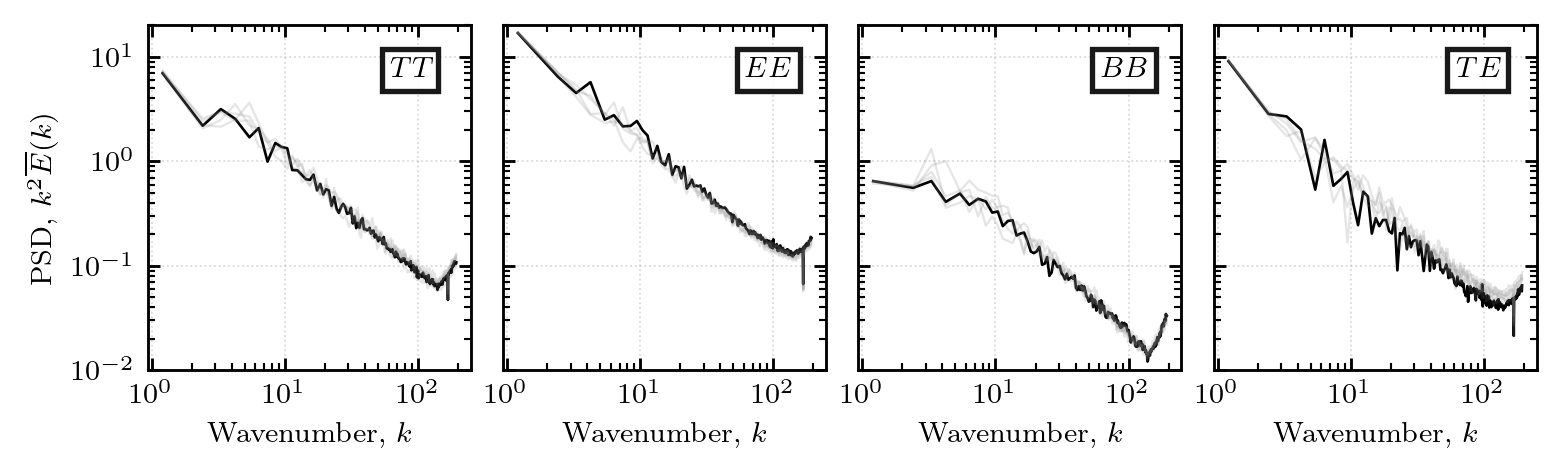

In [15]:
from src.utils import bbox_props

fig, ax = plt.subplots(1, 4, figsize=(3.5*2., 1.75), dpi=256)

# cols1 = sns.color_palette('rocket', n_colors=len(FEKS_TT)//4)
# cols2 = sns.color_palette('mako', n_colors=len(FEKS_TT)//4)
cols = ['gray' for _ in range(len(FEKS_TT))]
cols[0] = 'black'

for i in range(len(FEKS_TT)):
    if i == 0:
        ax[0].plot(FEKS_TT[i][0], FEKS_TT[i][0]**2 * FEKS_TT[i][1], color=cols[i], linewidth=0.75)
        ax[1].plot(FEKS_EE[i][0], FEKS_EE[i][0]**2 * FEKS_EE[i][1], color=cols[i], linewidth=0.75)
        ax[2].plot(FEKS_BB[i][0], FEKS_BB[i][0]**2 * FEKS_BB[i][1], color=cols[i], linewidth=0.75)
        ax[3].plot(FEKS_TE[i][0], FEKS_TE[i][0]**2 * FEKS_TE[i][1], color=cols[i], linewidth=0.75)
    else:
        ax[0].plot(FEKS_TT[i][0], FEKS_TT[i][0]**2 * FEKS_TT[i][1], color=cols[i], alpha=0.2, linewidth=0.65)
        ax[1].plot(FEKS_EE[i][0], FEKS_EE[i][0]**2 * FEKS_EE[i][1], color=cols[i], alpha=0.2, linewidth=0.65)
        ax[2].plot(FEKS_BB[i][0], FEKS_BB[i][0]**2 * FEKS_BB[i][1], color=cols[i], alpha=0.2, linewidth=0.65)
        ax[3].plot(FEKS_TE[i][0], FEKS_TE[i][0]**2 * FEKS_TE[i][1], color=cols[i], alpha=0.2, linewidth=0.65)

for axx in ax:
    pretty_axes(axx)
    axx.loglog()
    axx.set_xlabel('Wavenumber, $k$')
    axx.set_ylim((1e-2, 2e1))

ax[0].set_ylabel(r'PSD, $k^2 \overline{E}(k)$')
# ax[0].set_title('$TT$', fontsize=8.)
# ax[1].set_title('$EE$', fontsize=8.)
# ax[2].set_title('$BB$', fontsize=8.)
# ax[3].set_title('$TE$', fontsize=8.)

ax[0].text(0.75, 0.85, '$TT$', transform=ax[0].transAxes, color='black', bbox=bbox_props)
ax[1].text(0.75, 0.85, '$EE$', transform=ax[1].transAxes, color='black', bbox=bbox_props)
ax[2].text(0.75, 0.85, '$BB$', transform=ax[2].transAxes, color='black', bbox=bbox_props)
ax[3].text(0.75, 0.85, '$TE$', transform=ax[3].transAxes, color='black', bbox=bbox_props)

ax[1].set_yticklabels([])
ax[2].set_yticklabels([])
ax[3].set_yticklabels([])

fig.subplots_adjust(wspace=0.1)

# fig.savefig('plots/example_highlat_spectra.pdf', pad_inches=0.1, bbox_inches='tight')
